**1 Introduction**

It is good practice to examine the data first before making predictions on the data. Here I perform an extensive data analysis (EDA) on the data provided for the House Prices Competition. This document contains the following sections:
1. Importing Libraries
2. Importing the data
3. Have a quick look at the data
4. Investigate the target variable
5. Investigate the predictors
6. Check for missings
7. How are numeric features related to saleprice

**1: Importing libraries**

In [1]:
import pandas as pd             # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np              # linear algebra
import matplotlib.pyplot as plt # data visualisation
%matplotlib inline              
import seaborn as sns           # data visualisation

**2: Importing the data**

In [2]:
# Path of the file to read
train_file_path = '../input/train.csv'
test_file_path  = '../input/test.csv' 

# Fill in the line below to read the file into a variable home_data
train = pd.read_csv(train_file_path, index_col='Id')
test  = pd.read_csv(test_file_path, index_col='Id')

**3: Have a peak at the data**

In [3]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
test.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


Here we have the first rows of the train and the test dataset. The variable we have to predict is called *SalePrice* and it is located at the last column in the train dataset. The test dataset does not have a column SalePrice. 

The remaining columns can be used to predict this SalePrice and are present in both the train and test dataset. These features contain numbers or text values, there are also features with missing data (see NaN, which means not a number).

In [5]:
mystring = "The train data contains {0} rows (observations) and {1} columns (variables)."
print(mystring.format(train.shape[0], train.shape[1]))

mystring = "The test data contains {0} rows (observations) and {1} columns (variables)."
print(mystring.format(test.shape[0], test.shape[1]))

The train data contains 1460 rows (observations) and 80 columns (variables).
The test data contains 1459 rows (observations) and 79 columns (variables).


**4: Investigate the target variable SalePrice**

The target variable SalePrice is the one we have to predict. 

In [6]:
print(train['SalePrice'].describe())
print("median  ", train['SalePrice'].median())
print("Number of missings:", train['SalePrice'].isna().sum())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
median   163000.0
Number of missings: 0


The avarage saleprice for which a house was sold was 180.921 dollars, with a minimum of 34.900 and a maximum of 755.000 dollars. The median saleprice was 163.000 dollars.

In [7]:
#skewness and kurtosis
print("Skewness: %f" % train['SalePrice'].skew())
print("Kurtosis: %f" % train['SalePrice'].kurt())

Skewness: 1.882876
Kurtosis: 6.536282


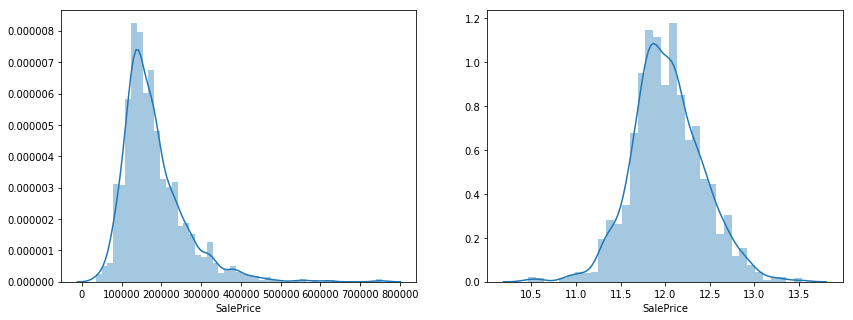

In [8]:
# Set the width and height of the two plots combined
f, axes = plt.subplots(1, 2, figsize=(14, 5))


# make distribution plot
sns.distplot(a=train['SalePrice'], ax=axes[0])
sns.distplot(a = np.log(train['SalePrice']), ax=axes[1])

In [9]:
#skewness and kurtosis
print("Skewness before log transformation: %f" % train['SalePrice'].skew())
print("Kurtosis before log transformation: %f" % train['SalePrice'].kurt())

print("Skewness after log transformation: %f" % np.log(train['SalePrice']).skew())
print("Kurtosis after log transformation: %f" % np.log(train['SalePrice']).kurt())

Skewness before log transformation: 1.882876
Kurtosis before log transformation: 6.536282
Skewness after log transformation: 0.121335
Kurtosis after log transformation: 0.809532


The plot above shows that the SalePrice has a right skewed distribution and a high kurtosis. When the log is taken we get a normal distribution. Since a lot of machine learning models assume that they are fed normally distributed data, I think we should give them normally distributed data.

**5: Examine the predictors**

In [10]:
# get a list of column names
var_names = list(train.drop(columns = ['SalePrice']).columns) 

print("There are {0} featues that can be used to predict the Saleprice.".format(len(var_names)))

There are 79 featues that can be used to predict the Saleprice.


In [11]:
train.drop(columns = ['SalePrice']).info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1460 entries, 1 to 1460
Data columns (total 79 columns):
MSSubClass       1460 non-null int64
MSZoning         1460 non-null object
LotFrontage      1201 non-null float64
LotArea          1460 non-null int64
Street           1460 non-null object
Alley            91 non-null object
LotShape         1460 non-null object
LandContour      1460 non-null object
Utilities        1460 non-null object
LotConfig        1460 non-null object
LandSlope        1460 non-null object
Neighborhood     1460 non-null object
Condition1       1460 non-null object
Condition2       1460 non-null object
BldgType         1460 non-null object
HouseStyle       1460 non-null object
OverallQual      1460 non-null int64
OverallCond      1460 non-null int64
YearBuilt        1460 non-null int64
YearRemodAdd     1460 non-null int64
RoofStyle        1460 non-null object
RoofMatl         1460 non-null object
Exterior1st      1460 non-null object
Exterior2nd      1460 non-

There are three two types of features: 
* numerical features (float64, int64), n = 36
* features containing text values (object), n= 43
It is likely that numerical features represent continuous features and features containing text are categorical.
We can also observe that the data set contains features with missing values. Features with missing data need to be dropped or imputed since XGBoost cannot handle data with missing values.

In [12]:
# Here I assume that columns containing text values (dtypes == 'object') are categorical features
s = (train.dtypes == 'object')
cat_vars = list(s[s].index)
# I manually checked for other categorical features containing numeric values
other_cat_vars = ['MSSubClass', 'OverallQual', 'OverallCond', ]
categorical_vars = cat_vars + other_cat_vars

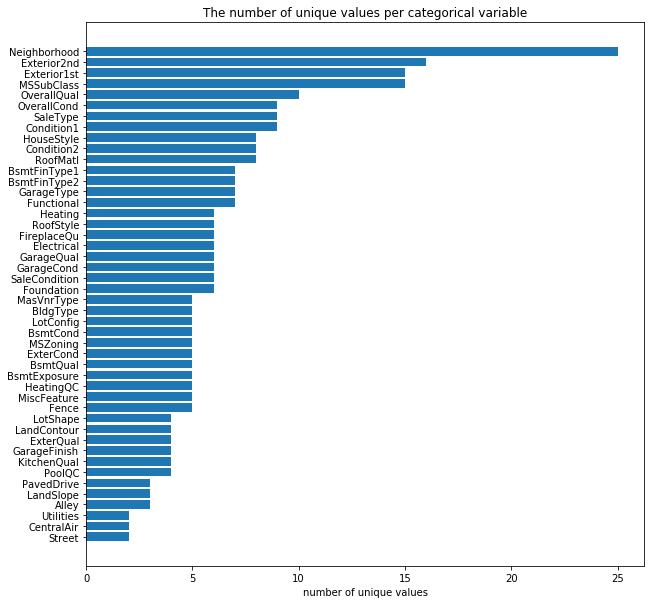

In [13]:
# make empty dictionary
data = {}

# get number of unique values per variable
for i in categorical_vars:
    variables = i
    n_unique_values = len(train[i].unique().tolist())
    data[i] = (variables, n_unique_values)
    
# go from dictionary to pandas dataframe    
df_cat_vars = pd.DataFrame.from_dict(data, orient='index', columns=['variables','n_unique_values'])

# sort values by n_unique values
ordered_df = df_cat_vars.sort_values(by = ['n_unique_values'], ascending=True)

# make horizontal barchart to visualize results
plt.figure(figsize=(10,10))                                       #set size of figure to 10x10 inches
plt.barh(ordered_df.variables, ordered_df.n_unique_values)        #plot barchart
plt.xlabel('number of unique values')                             #name x-label
plt.title('The number of unique values per categorical variable') #give plot a title
plt.show()


The number of categories varies from two to 25 different categories. Keep in mind that it might be good idea to reduce the number of categories, especially when a feature has more than 10 categories or if a categorie contains a few obervations. Perhaps categories with only a few observations can combined into a category called remaining.

**6: Check for missings**

We already observed that the data contains missing values. This ranges some questions:
1. How many missings do we have?
2. Why are they missing?
3. Are these values missing at random (MAR)? 

Lets start with the first question, how many missings do we have. It is always a good idea to visualize the number of missings.

In [14]:
# get number of missings per column in train and test set
mistrain = train.isnull().sum().to_frame()
mistest = test.isnull().sum().to_frame()

# give column the name nMissings
mistrain.columns = ['nMissings']
mistest.columns = ['nMissings']

# make new columns that gives information about missing percentage
mistrain['percMissing'] = mistrain['nMissings']/1460
mistest['percMissing'] = mistest['nMissings']/1459

# select only rows with nMissings >= 1
mistrain = mistrain[mistrain.nMissings >= 1]
mistest = mistest[mistest.nMissings >= 1]

# sort values by nMissings values
ordered_df_train = mistrain.sort_values(by = ['nMissings'], ascending=False)
ordered_df_test = mistest.sort_values(by = ['nMissings'], ascending=False)

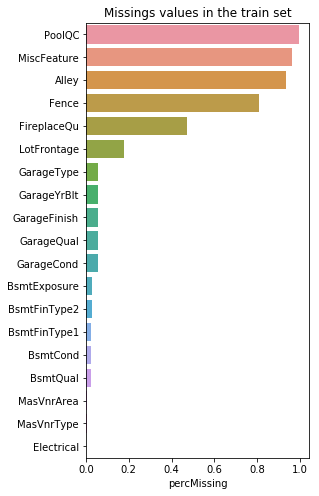

In [15]:
# set figure size
plt.figure(figsize=(4,8))          

# add title
plt.title('Missings values in the train set')  

# add lable for horizontal axis
plt.xlabel('Percentage of missing values')                            

# make barplot
sns.barplot(y = ordered_df_train.index, x = ordered_df_train['percMissing'])   

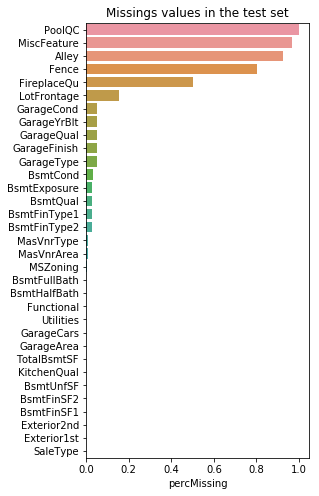

In [16]:
# set figure size
plt.figure(figsize=(4,8))          

# add title
plt.title('Missings values in the test set')  

# add lable for horizontal axis
plt.xlabel('Percentage of missing values')

# make barplot
sns.barplot(y=ordered_df_test.index, x=ordered_df_test['percMissing'])      

From the charts we can observe that there are 19 features with missing values in the train data set and 33 features with missing values in the test set.

There are four features with 50 percent or more missings in both the train and test set. These features include: PoolQC, MiscFeature, Alley, Fence and FireplaceQC. Lets check these features using information from datadescription. I did this manually. For the features PoolQC, MiscFeature, Alley, Fence, FireplaceQu, the information from the datadescription.txt file tells us that a missing value indicates that the feature is not present in the house. 

The feature LotFrontage has about 20 percent missing values in both the train and test set. Information from the datadescription file tells us that this feature gives information of the length of street connected to the front of the proporty and it is a continous feature.

The following features have less that 10 percent missing values: GarageType, GarageQual, GarageCond, BsmtFinType2, BsmtExposure, BsmtFinType1, BsmtCond, BsmtQual. The data from the datadescription.txt file tells us that a missing value indicates that the feature is not present in the house.

Feature that need to be checked: LotFrontage, Electrical, MasVnrArea, MasVnrType

The feature LotFrontage describes how much feet of street is connected to the property. In about 300 observations this value is missing. For the other three features, Electrical, MasVnrArea and MasVnrType only a few observations are missing.


**7: How are numeric features related to SalePrice**

Lets check how numeric features are related to SalePrice. We start with the features that represent size. First we calculate the correlation coefficients between all these size related features and SalePrice, next these values are visualized in a heatmap.

In [17]:
# select target variable SalePrice and features related to size
my_vars = ['SalePrice', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea']

# get the correlation coefficients between these features.
corr = train[my_vars].corr()

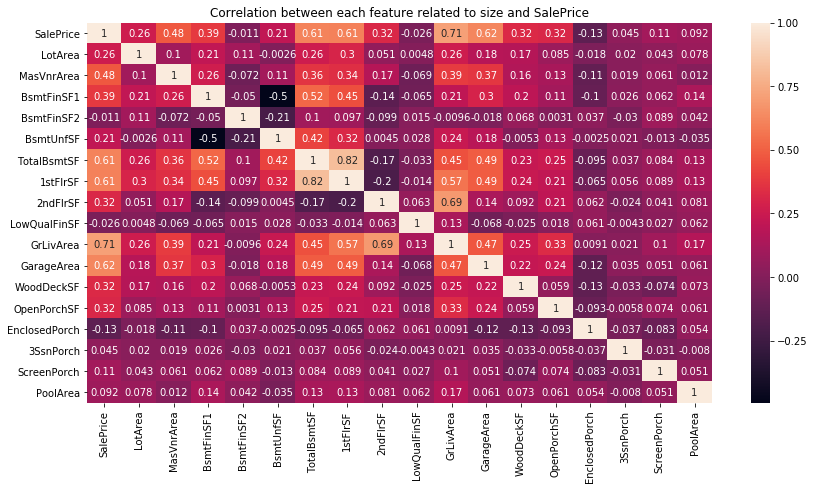

In [18]:
# Set the width and height of the figure
plt.figure(figsize=(14,7))

# Add title
plt.title("Correlation between each feature related to size and SalePrice")

# Heatmap showing average arrival delay for each airline by month
sns.heatmap(data=corr, annot=True)

*SalePrice* shows strong correlations with the features *GrLivArea* (0.71), *GarageArea* (0.62), *1stFlSF* (0.61), *TotalBsmtSF* (0.61). MasVnrArea (0.48) shows a moderate correlation with Saleprice . The remaining features show weak () or very weak (PoolArea, ScreenPorch, 3SsnPorch, EnclosedPorch, BsmtFinSF2) correlations with SalePrice.

Note that if a feature is not present a zero is given for the area. Lets set all zero to missing!

In [19]:
# set zeros to Nan, and get correlation coefficients.
mydata = train[my_vars].replace(0, np.nan)

In [20]:
# check how many missings we have per feature
missings = mydata.isnull().sum().to_frame()

# give column the name nMissings
missings.columns = ['nMissings']

# make new columns that gives information about missing percentage
missings['percMissing'] = missings['nMissings']/1460

# sort values by nMissings values
ordered_missings = missings.sort_values(by = ['nMissings'], ascending=False)
ordered_missings

,nMissings,percMissing
PoolArea,1453,0.995205
3SsnPorch,1436,0.983562
LowQualFinSF,1434,0.982192
ScreenPorch,1344,0.920548
BsmtFinSF2,1293,0.885616
EnclosedPorch,1252,0.857534
MasVnrArea,869,0.595205
2ndFlrSF,829,0.567808
WoodDeckSF,761,0.521233
OpenPorchSF,656,0.449315


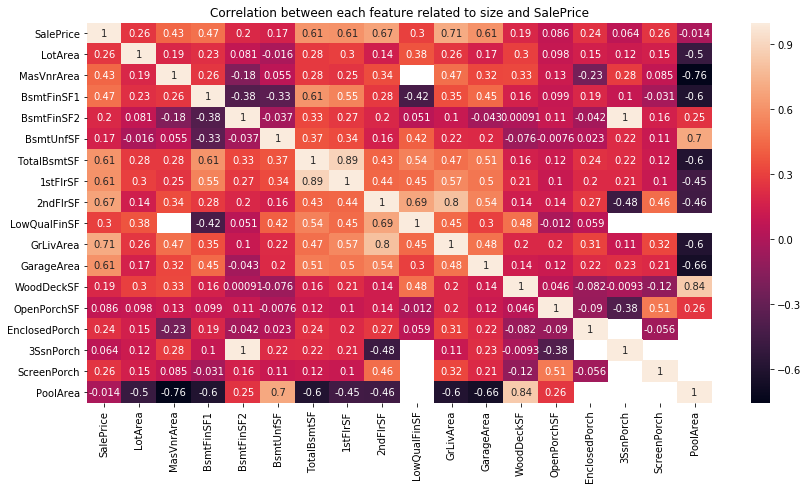

In [21]:
corr = mydata.corr()

# Set the width and height of the figure
plt.figure(figsize=(14,7))

# Add title
plt.title("Correlation between each feature related to size and SalePrice")

# Heatmap showing correlation coefficients
sns.heatmap(data=corr, annot=True)

Some correlations coefficients are changed and other are not. Especially the features with a lot of zero values have changed, since these zero's no longer contribute to the correlation coefficient. We already knew that SalePrice has a non-normal distribution. Lets also check the distribution of the other numeric features that have non-missing values 

In [22]:
my_vars = ['1stFlrSF', 'LotArea', 'GrLivArea', 'SalePrice']
mydata = train[my_vars].replace(0, np.nan)
for i in my_vars:
    print(i)
    print("Skewness before log transformation: %f" % mydata[i].skew())
    print("Kurtosis before log transformation: %f" % mydata[i].kurt())

1stFlrSF
Skewness before log transformation: 1.376757
Kurtosis before log transformation: 5.745841
LotArea
Skewness before log transformation: 12.207688
Kurtosis before log transformation: 203.243271
GrLivArea
Skewness before log transformation: 1.366560
Kurtosis before log transformation: 4.895121
SalePrice
Skewness before log transformation: 1.882876
Kurtosis before log transformation: 6.536282


Also here a lot of non-normal distributions. Lets get the skewness and kurtosis after log transformations.

In [23]:
for i in my_vars:
    print(i)
    print("Skewness after log transformation: %f" % np.log(mydata[i]).skew())
    print("Kurtosis after log transformation: %f" % np.log(mydata[i]).kurt())

1stFlrSF
Skewness after log transformation: 0.079157
Kurtosis after log transformation: 0.150808
LotArea
Skewness after log transformation: -0.137994
Kurtosis after log transformation: 4.713358
GrLivArea
Skewness after log transformation: -0.006995
Kurtosis after log transformation: 0.282603
SalePrice
Skewness after log transformation: 0.121335
Kurtosis after log transformation: 0.809532


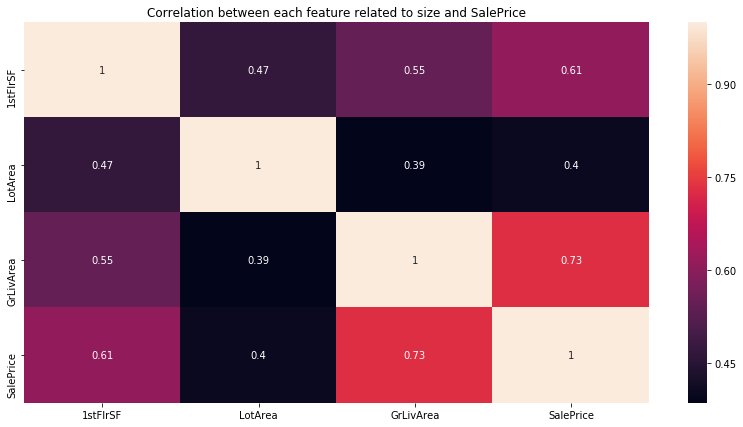

In [24]:
corr =np.log(mydata[my_vars]).corr()

# Set the width and height of the figure
plt.figure(figsize=(14,7))

# Add title
plt.title("Correlation between each feature related to size and SalePrice")

# Heatmap showing correlation coefficients
sns.heatmap(data=corr, annot=True)

How about categorical variables

In [25]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [26]:
train.MSZoning.unique()



array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object)

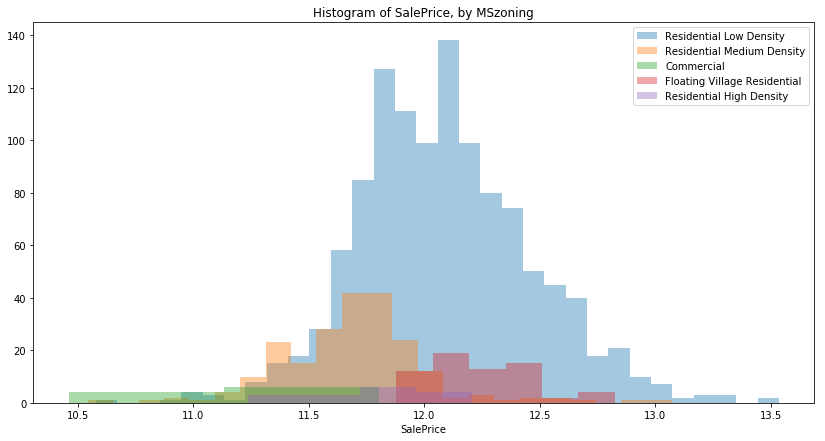

In [27]:
# break data into different parts
rl = train[train.MSZoning == 'RL']
rm = train[train.MSZoning == 'RM']
c = train[train.MSZoning == 'C (all)']
fv = train[train.MSZoning == 'FV']
rh = train[train.MSZoning == 'RH']

# Set the width and height of the figure
plt.figure(figsize=(14,7))

# Histograms for each species
sns.distplot(a = np.log(rl['SalePrice']), label="Residential Low Density", kde=False)
sns.distplot(a = np.log(rm['SalePrice']), label="Residential Medium Density", kde=False)
sns.distplot(a = np.log(c['SalePrice']), label="Commercial", kde=False)
sns.distplot(a = np.log(fv['SalePrice']), label="Floating Village Residential", kde=False)
sns.distplot(a = np.log(rh['SalePrice']), label="Residential High Density", kde=False)

# Add title
plt.title("Histogram of SalePrice, by MSzoning")

# Force legend to appear
plt.legend()